# Navigation tutorial based on place cell activity from the Buzsáki lab  
homepage: https://buzsakilab.com/wp/  
source: https://crcns.org/data-sets/hc/hc-11/about-hc-11  
mouse name: Achilles


We will learn about place cells and the position code by decoding spatial location from hippocampal neural activity.

We use a new dataset, introduced below. The roadmap is:  
Section 1. You load the data and familiarizes with its structure   
Sec. 2. Plot the behavioral data (measured position)  
Sec. 3. Plotting the tuning curves (TC) of the neurons: place fields
Sec. 4. Step by step guide for Bayesian decoding of position
Sec. 5. Decoding: measure performance, confusion matrix

Finally, the last chapter describes the homework problems.


prepared by Balazs B Ujfalussy, 2026. balazs.ujfalussy@gmail.com, https://koki.hun-ren.hu/researchgroups/biological-computation/people#ujfalussy-balazs-skgtwtfggo3ftg9p


### About the data
For detailed information please follow the link above. In brief, the rat was running back and forth on a linear track for reward. The activity of multiple hippocampal neurons have been recorded together with the position of the animal. 

The hippocampus is a brain region involved in spatial navigation. The task demands are fundementally different during movement versus immobile periods. Accordingly, the hippocampal neuronal activity is different during locomotion than during stops. Therefore the data should be analysed separately for locomotion and stops. 

In the original experiment neuronal activity during a short sleep episode before and after the navigation task (maze epoch) was also recorded. Here we selected data during maze epochs (no pre and post sleep). Spike times and positions have been rounded to 2 digits (10 ms and 1 cm precision). Cells have been renumbered.

position.txt: first column: time (s) second column: position of the rat on a linear track in meter

spikes.txt spike times (first column, s) and ID of ~120 pyramidal cells from the hippocampus


### Load some useful libraries

*numpy* - to work with arrays (https://numpy.org/), *matplotlib* - to create simple plots (https://matplotlib.org/), *scipy.interpolate* to convert from time to position (https://docs.scipy.org/doc/scipy/reference/interpolate.html)

In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.stats import lognorm
from scipy.stats import poisson
from scipy.optimize import minimize_scalar

%matplotlib widget

## 1. Load the data

In [2]:
pos = np.genfromtxt("datasets/HC11/position_mm.txt")
spikes = np.genfromtxt("datasets/HC11/spikes_ms.txt")
print(pos.shape)
print(spikes.shape)


(80762, 2)
(270829, 2)


## 2. Plot the position data
We plot the position as a function of time

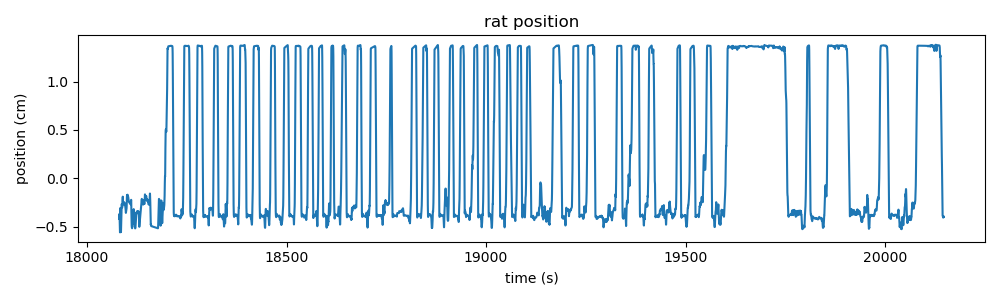

In [3]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(pos[:,0], pos[:, 1])
ax.set_title('rat position')
ax.set_xlabel('time (s)')
ax.set_ylabel('position (cm)')
fig.tight_layout()
# plt.savefig('datasets/HC11/position.pdf')

### Find running sections, separate up versus down

We only include data during running - so we remove all datapoints below a certain speed threshold. We also remove short segments (shorter than 20 datapoints - 0.5 s) and datapoints on the two ends of the corridor. 

In [4]:
speed_threshold = 0.05 # m/s
dt_pos = np.mean(np.diff(pos[:,0])) # the time resolution of the position recordings
speed = np.diff(pos[:,1]) / dt_pos
speed = np.hstack((speed[0], speed))
iii_run = np.logical_and(np.abs(speed) > speed_threshold, np.logical_and(pos[:,1] > -0.25, pos[:,1] < 1.25))
ii_run = np.convolve(iii_run, np.ones(20)/20, mode='same')
ii_run[ii_run < 1] = 0
i_run = np.convolve(ii_run, np.ones(20)/20, mode='same')
i_run[i_run > 0] = 1
i_down = np.logical_and(speed < 0, i_run)
i_up = np.logical_and(speed > 0, i_run)

To check the results, we plot the selected sections using different colors.

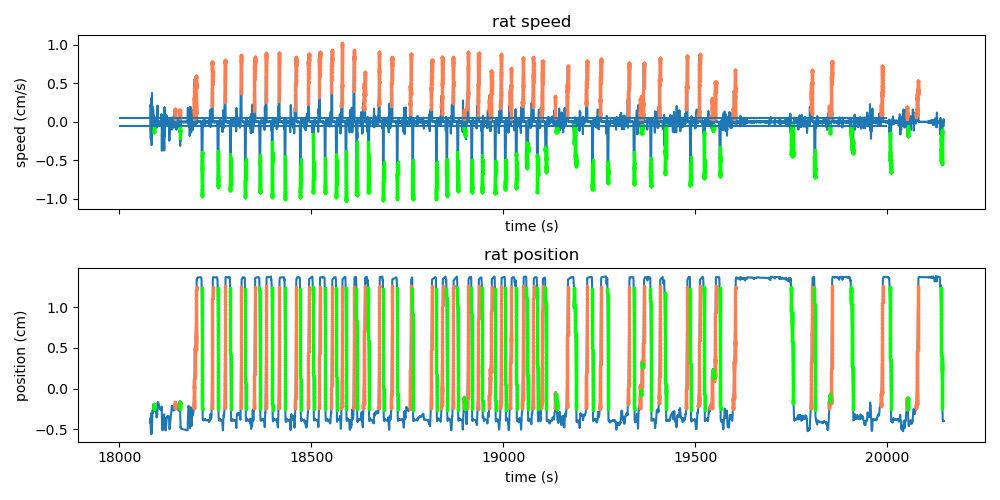

In [5]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (10, 5))
ax1.plot(pos[:,0], speed)
ax1.plot(pos[i_up,0], speed[i_up], '.', c='coral', markersize=3)
ax1.plot(pos[i_down,0], speed[i_down], '.', c='lime', markersize=3)
ax1.hlines((0.05, -0.05), 18000, 20000)
ax1.set_title('rat speed')
ax1.set_xlabel('time (s)')
ax1.set_ylabel('speed (cm/s)')

ax2.plot(pos[:,0], pos[:,1])
ax2.plot(pos[i_up,0], pos[i_up,1], '.', c='coral', markersize=3)
ax2.plot(pos[i_down,0], pos[i_down,1], '.', c='lime', markersize=3)
ax2.set_title('rat position')
ax2.set_xlabel('time (s)')
ax2.set_ylabel('position (cm)')
f.tight_layout()

## 3. Calculating and plotting the ratemaps

### Calculating ratemaps from data

We use the function histogram to calculate the number of timebins spent at each position

In [6]:
posbins = np.arange(-0.3, 1.31, 0.05)
posbin_centers = np.arange(-0.275, 1.31, 0.05)
n_up, edges = np.histogram(pos[i_up,1], posbins) # the number of bins in each position during up runs
T_up = n_up * dt_pos + dt_pos # we add one bin into each position to prevent division by zero
n_down, edges = np.histogram(pos[i_down,1], posbins) # same for down
T_down = n_down * dt_pos + dt_pos

In [7]:
T_up

array([ 0.02559991, 10.67516282, 11.46876006, 10.03516505,  7.44957406,
        6.06717887,  5.52958074,  4.73598351,  5.32478146,  4.68478369,
        5.32478146,  4.55678413,  5.14558208,  4.04478591,  3.83998663,
        3.96798618,  3.73758698,  3.99358609,  3.83998663,  3.60958743,
        3.25118868,  3.02078948,  2.99518957,  2.86719001,  2.81599019,
        2.86719001,  2.73919046,  2.81599019,  2.96958966,  3.3023885 ,
        3.83998663,  1.10079617])

In [8]:
n_down

array([ 45, 241, 221, 205, 168, 152, 125, 125, 136, 147, 144, 145, 139,
       117, 116, 119, 111, 117, 115, 113, 113, 117, 124, 128, 134, 132,
       144, 155, 157, 186, 182,   0])

We calculate the ratemap of the cells in a similar way. To do this, we need to 
- select the spikes of cell i
- find those spikes that belong to the up or down runs
- find the position of the spikes  

To achieve this we will make extensive use of the function interp1d() (https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html) that linearly approximates position or running direction for spike times not included in the position measurement.


In [9]:
# We define a function here that returns the approximate position for any time point
Fpos_time = interp1d(pos[:,0], pos[:,1], fill_value="extrapolate") 
# this F_up function returns 1 for those times that belong to up runs
F_up = interp1d(pos[:,0], i_up, bounds_error=False, fill_value=0)
# this F_down function returns 1 for those times that belong to up runs
F_down = interp1d(pos[:,0], i_down, bounds_error=False, fill_value=0)

In [10]:
spikemaps_up = np.zeros((121,32))
spikemaps_down = np.zeros((121,32))
ratemaps_up_all = np.zeros((121,32))
ratemaps_down_all = np.zeros((121,32))

In [11]:
mu_up = np.zeros(121) # place field means
mu_down = np.zeros(121)

for cellid in np.arange(121): # = 6 # the ID of the cell to plot
#     print(cellid)
    i_cell = np.where(spikes[:,1] == cellid)[0] # the index where the cell was active - spikes were emitted
    celltime = spikes[i_cell,0]

    ### find the spikes during up and down runs
    up_spikes = np.where(F_up(celltime) == 1)
    up_pos = Fpos_time(celltime[up_spikes])
    up_hist, edges = np.histogram(up_pos, posbins)
    spikemaps_up[cellid,:] = up_hist
    rr_up = (up_hist + 0.1*dt_pos) / T_up # we use a simple trick here: add 0.1 to the spike counts - see below
    ratemaps_up_all[cellid,:] = np.convolve(rr_up, np.ones(5)/5, mode='same')
    mu_up[cellid] = np.sum(posbin_centers * ratemaps_up_all[cellid,:]) / np.sum(ratemaps_up_all[cellid,:])

    
    down_spikes = np.where(F_down(celltime) == 1)
    down_pos = Fpos_time(celltime[down_spikes])
    down_hist, edges = np.histogram(down_pos, posbins)
    spikemaps_down[cellid,:] = down_hist
    rr_do = (down_hist + 0.1*dt_pos) / T_down # we use a simple trick here: add 0.1 to the spike counts - see below
    ratemaps_down_all[cellid,:] = np.convolve(rr_do, np.ones(5)/5, mode='same')
    mu_down[cellid] = np.sum(posbin_centers * ratemaps_down_all[cellid,:]) / np.sum(ratemaps_down_all[cellid,:])
    

We don't want to have 0 rate in the rate matrix, as it can really bias decoding - if the rate is 0 then it is impossible to observe a spike there. So we add pseudo-counts - this is a simple trick, quite efficient, but not really smart.

### We select cells that are active either during up or down runs.

In [12]:
active_cells_down = np.where(np.sum(spikemaps_down, axis=1) > 200)[0]
active_cells_up = np.where(np.sum(spikemaps_up, axis=1) > 200)[0]
active_cells = np.unique(np.hstack((active_cells_up, active_cells_down)))
ratemaps_up = ratemaps_up_all[active_cells,:]
ratemaps_down = ratemaps_down_all[active_cells,:]
mus_up = mu_up[active_cells]
mus_down = mu_down[active_cells]

We sort the cells by their peak location in up and down runs, separately

In [13]:
peak_loc_up = np.argmax(ratemaps_up, axis=1)
sortindex_up = np.argsort(peak_loc_up)
# sortindex_up = np.argsort(mus_up)
cells_up = active_cells[sortindex_up]
rates_up = ratemaps_up[sortindex_up,:]

peak_loc_down = np.argmax(ratemaps_down, axis=1)
sortindex_down = np.argsort(peak_loc_down)
# sortindex_down = np.argsort(mus_down)
cells_down = active_cells[sortindex_down]
rates_down = ratemaps_down[sortindex_down,:]

Plot the sorted ratemaps

[Text(0.5, 1.0, 'DOWN, sorted by down'), Text(0.5, 0, 'position bin')]

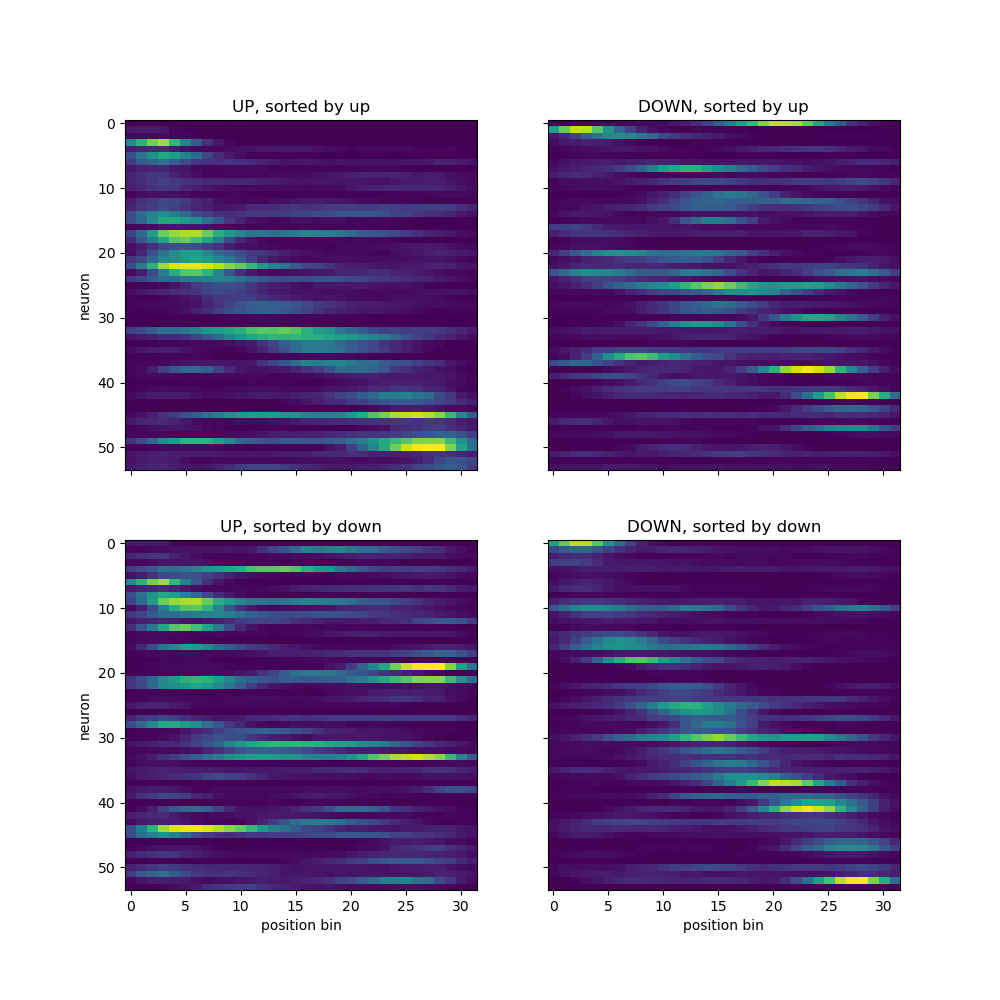

In [14]:
f, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10,10))
axs[0,0].imshow(ratemaps_up[sortindex_up,:], aspect='auto')
axs[0,0].set(title='UP, sorted by up', ylabel='neuron')
axs[0,1].imshow(ratemaps_down[sortindex_up,:], aspect='auto')
axs[0,1].set_title('DOWN, sorted by up')
axs[1,0].imshow(ratemaps_up[sortindex_down,:], aspect='auto')
axs[1,0].set(title='UP, sorted by down', ylabel='neuron', xlabel='position bin')
axs[1,1].imshow(ratemaps_down[sortindex_down,:], aspect='auto')
axs[1,1].set(title='DOWN, sorted by down', xlabel='position bin')

### Plotting all the tuning curves.  
- first: normalized to their max rate  
- next: absolute firing rate as a function of position 

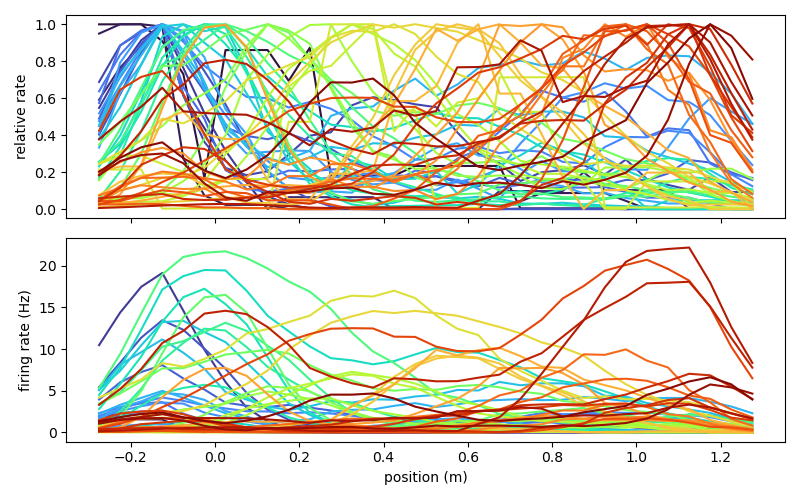

In [15]:
import matplotlib as mpl
cmap = mpl.colormaps['turbo']
f, axs = plt.subplots(2,1, figsize=(8,5), sharex=True)
N_cells = len(sortindex_up)
for i, i_cell in enumerate(sortindex_up):
    rmap = ratemaps_up[i_cell,:]
    axs[0].plot(posbin_centers, rmap/np.max(rmap), color=cmap(i/N_cells))
    axs[1].plot(posbin_centers, rmap, color=cmap(i/N_cells))

axs[0].set(ylabel='relative rate')
axs[1].set(xlabel='position (m)', ylabel='firing rate (Hz)')
f.tight_layout()
# plt.savefig('place_cells.pdf')

### Plot the activity of cells during run, 

sorted by their place field peak during up run sessions.

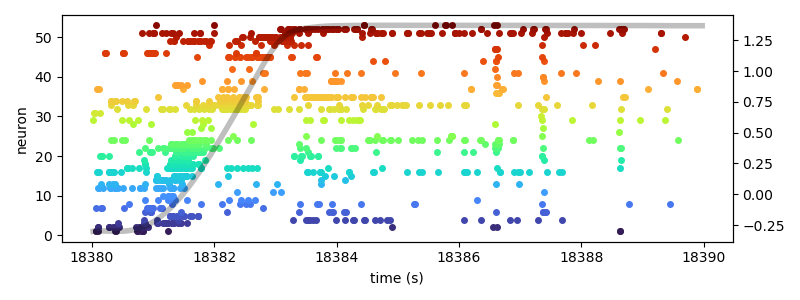

In [16]:
f, axs = plt.subplots(1,1, figsize=(8,3))
tmin = 18380 # 18312
tmax = 18390 # 18320
for i, i_cell in enumerate(active_cells[sortindex_up]):
    ii_sp = np.where((spikes[:,1] == i_cell) & (spikes[:,0] > tmin) & (spikes[:,0]<tmax))[0] # the index where the cell was active - spikes were emitted
    tt_sp = spikes[ii_sp,0]
    axs.scatter(tt_sp, np.ones(len(tt_sp))*i, s=16, color=cmap(i/N_cells))
axs.set(xlabel='time (s)', ylabel='neuron')

posax = axs.twinx()
posindex = np.flatnonzero((pos[:,0]> tmin) & (pos[:,0] < tmax))
posax.plot(pos[posindex,0], pos[posindex, 1], color='k', alpha=0.25, linewidth=4)


f.tight_layout()
# plt.savefig('place_cell_spikes.pdf')

## 4. Bayesian decoding step by step

### Preparing a raster of spikes using a given temporal resolution

To perform decoding, we will need to bin the spikes in time. We will forst use 50 ms time bins. 

In [17]:
dt = 0.05 # temporal resolution of decoding - we will decode in 50 ms time bins
time_axis = np.arange(min(pos[:,0]), max(pos[:,0])+dt, dt)
position = Fpos_time(time_axis)
raster = np.zeros((len(active_cells), len(time_axis))) # spike counts at 200 Hz - 0 no spike, 1, 2, ...
k_cell = 0
for i_cell in active_cells[sortindex_up]:
    ii_sp = np.where(spikes[:,1] == i_cell)[0] # the index where the cell was active - spikes were emitted
    cell_time = spikes[ii_sp,0]
    for i_sp in (np.floor((cell_time - min(time_axis)) / dt)):
        raster[k_cell, int(i_sp)] = raster[k_cell, int(i_sp)] + 1
    k_cell = k_cell + 1

i_raster_up = np.where(F_up(time_axis).astype(int))[0] # index of the relevant data
raster_up = raster[:, i_raster_up]
pos_up = position[i_raster_up]
i_raster_down = np.where(F_down(time_axis).astype(int))[0] # index of the relevant data
raster_down = raster[:, i_raster_down]
pos_down = position[i_raster_down]


Also, to decode, we will need to find the epoch where the animal is running in the right direction.

We collect all the relevant indexes into a numpy array

In [18]:
## finding the start and the end of the up runs
upstarts = np.flatnonzero(np.diff(i_raster_up) > 2)
upstarts

array([  12,   23,   51,   81,  132,  180,  225,  268,  314,  357,  400,
        445,  488,  528,  566,  611,  650,  729,  782,  828,  890,  946,
       1008, 1055, 1084, 1140, 1196, 1227, 1246, 1297, 1347, 1398, 1427,
       1487, 1542, 1551, 1614, 1629, 1698, 1756, 1820, 1875, 1911, 1944,
       1997, 2059, 2113, 2132, 2183, 2193, 2240, 2316, 2383, 2435, 2514,
       2527, 2541, 2602, 2681, 2691, 2705])

This is how the data for a single run looks like:

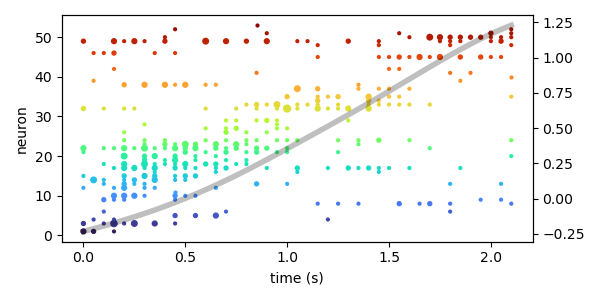

In [19]:
f, axs = plt.subplots(1,1, figsize=(6,3))
ii = 6
imin = upstarts[ii]+1 # 226
imax = upstarts[ii + 1]+1 # 269

itime = i_raster_up[imin:imax]
time_select = time_axis[itime]
for i_cell in sortindex_up:
    ispike = np.flatnonzero(raster[i_cell,itime])
    axs.scatter(time_select[ispike]-time_select[0], np.ones(len(ispike))*i_cell, s=raster[i_cell,itime][ispike]*4, color=cmap(i_cell/N_cells))

posax = axs.twinx()
posindex = np.flatnonzero((pos[:,0]> tmin) & (pos[:,0] < tmax))
posax.plot(time_select-time_select[0], pos_up[imin:imax], color='k', alpha=0.25, linewidth=4)
axs.set(xlabel='time (s)', ylabel='neuron')
f.tight_layout()
# plt.savefig('raster_run_dt50ms.pdf')

### Illustrations of the likelihood

We start with a simple set of assumptions:
1. Each neuron fires independently as a function of position $x$ with firing rate $\lambda_i(x)$.
2. If we have $\Delta t$ time windows, the mean spike count of neuron $i$ is $\mu_i(x) = \Delta t \lambda_i(x)$.
3. The spike counts $s_i$ are generated by a Poisson process, so $P(s_i|\mu_i(x)) = \text{Poisson}(\mu_i(x))$
4. From 1. and 3., the probability of a set of spikes in the population is $P(\mathbf{s}| x) = \prod_i P(s_i|\mu_i(x))$

Static Bayesian Decoding is just applying Bayes rule:
$P(x | \mathbf{s}) = \frac{P(\mathbf{s}| x)P(x)}{P(\mathbf{s})} $

Here we use a uniform prior over locations in wich case all what we need to do is to multiply the liklihood functions associated with each cell and then renormalize the posterior:
$P(x | \mathbf{s}) \propto \prod_i P(s_i| \lambda_i(x))$.

In practice, these likelihood values can be very small (e.g. 1/1000). Multiplying many small numbers easily exceeds the numerical precision of the computer, so it is better to calculate the log of the likelihood and the the SUM (and not the lroduct) of the logs:
$\log P(x | \mathbf{s}) \propto \sum_i \log P(s_i| \lambda_i(x))$.



In the next plot I show the the likelihood of the position for the cell 9 firing 0, 2 and 4 spikes.

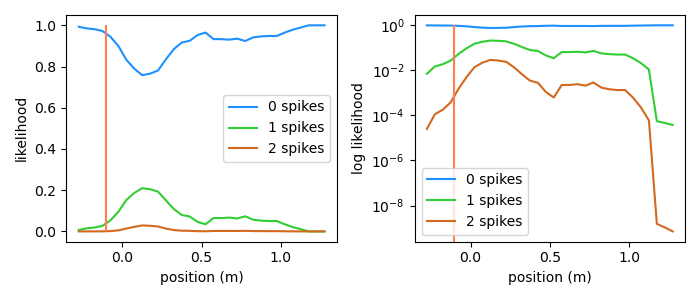

In [22]:
i_cell = 9
i_bin = 232
f, [ax1, ax2] = plt.subplots(1, 2, figsize = (7, 3))
ax1.plot(posbin_centers, poisson.pmf(0, ratemaps_up[i_cell,:] * dt), c='dodgerblue', label='0 spikes')
ax1.plot(posbin_centers, poisson.pmf(1, ratemaps_up[i_cell,:] * dt), c='limegreen', label='1 spikes' )
ax1.plot(posbin_centers, poisson.pmf(2, ratemaps_up[i_cell,:] * dt), c='chocolate', label='2 spikes' )
ax1.vlines(pos_up[i_bin], 0, 1, color='coral')
ax1.legend()
ax1.set_xlabel('position (m)')
ax1.set_ylabel('likelihood')

ax2.plot(posbin_centers, poisson.pmf(0, ratemaps_up[i_cell,:] * dt), c='dodgerblue', label='0 spikes')
ax2.plot(posbin_centers, poisson.pmf(1, ratemaps_up[i_cell,:] * dt), c='limegreen', label='1 spikes' )
ax2.plot(posbin_centers, poisson.pmf(2, ratemaps_up[i_cell,:] * dt), c='chocolate', label='2 spikes' )
ax2.vlines(pos_up[i_bin], 0, 1, color='coral')
ax2.legend()
ax2.set_xlabel('position (m)')
ax2.set_ylabel('log likelihood')
ax2.set(yscale='log')
f.tight_layout()

### Interpolation to improve resolution...

In [24]:
posbin_centers

array([-0.275, -0.225, -0.175, -0.125, -0.075, -0.025,  0.025,  0.075,
        0.125,  0.175,  0.225,  0.275,  0.325,  0.375,  0.425,  0.475,
        0.525,  0.575,  0.625,  0.675,  0.725,  0.775,  0.825,  0.875,
        0.925,  0.975,  1.025,  1.075,  1.125,  1.175,  1.225,  1.275])

In [36]:
from scipy.optimize import minimize_scalar
from scipy.stats import norm

post = norm.pdf(posbin_centers, 0.04, 0.04)
Fpost = interp1d(posbin_centers, -1*post, fill_value="extrapolate", kind='cubic') 
res = minimize_scalar(Fpost, bounds=(-0.3, 1.3), method='bounded')

In [39]:
res.x # the maximum of the curve is at 0.036. 
# It is much closer to the true peak at 0.04 than the center of the bin with the largest probability (0.025)

0.03621700535473144

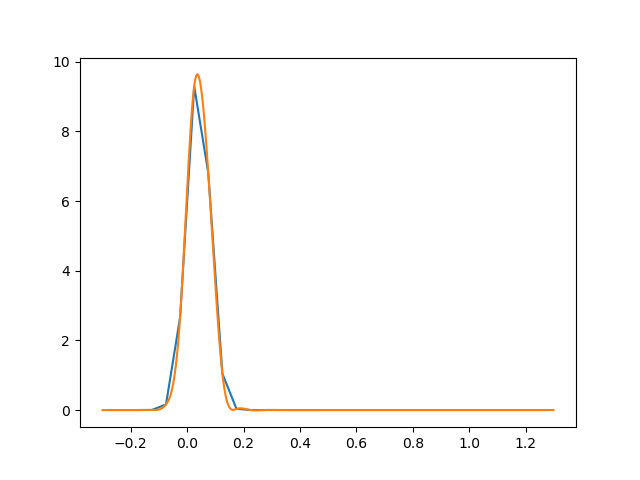

In [40]:
f, ax = plt.subplots()
ax.plot(posbin_centers, post)
xx = np.arange(-0.3, 1.3, 0.001)
ax.plot(xx, -1*Fpost(xx))

###  Step by step Bayesian decoding 

We start by selecting a particular time bin, let`s say bin 232. 
We plot the activity of the cells in this time bin. What these spikes tell us about the position of the animal? 

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 3. 0. 1. 4. 2. 2. 0. 4. 1.
 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 3. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0.]


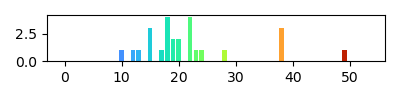

In [41]:
i_bin = 232
cmap = mpl.colormaps['turbo']

sp_bin = raster_up[:,i_bin]

f, ax = plt.subplots(1,1, figsize=(4,1), sharex=True)
for i_cell in np.arange(N_cells):
    ax.bar(i_cell, sp_bin[i_cell], color=cmap(i_cell/N_cells))
f.tight_layout()
# plt.savefig('spikes_bar232.pdf')

print(sp_bin)

Plot the ratemap of the neurons. The width of the curve is proportional to the number of spikes observed.

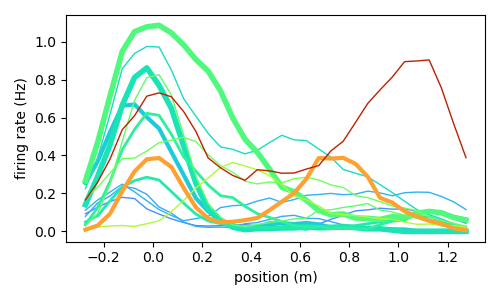

In [42]:
f, ax1 = plt.subplots(1, 1, figsize = (5, 3))

for i_cell in np.flatnonzero(sp_bin):
    ax1.plot(posbin_centers, rates_up[i_cell,:] * dt, color=cmap(i_cell/N_cells), linewidth=sp_bin[i_cell])
# ax1.vlines(pos_up[i_bin], 0, max(rates_up[i_cell,:]), color='k')
ax1.set_xlabel('position (m)')
ax1.set_ylabel('firing rate (Hz)')
f.tight_layout()

### Plotting the likelihood, log likelihood and the posterior

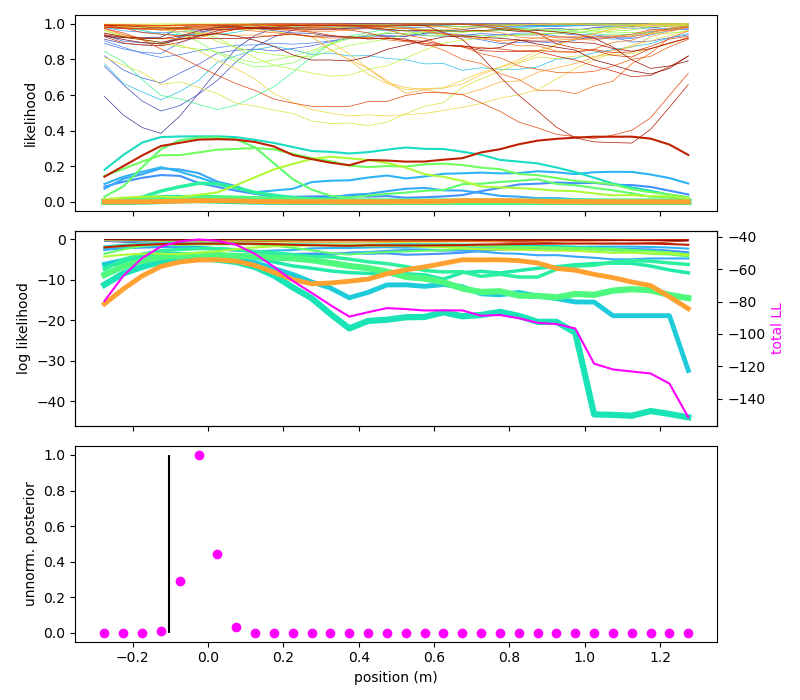

In [43]:
logpost = np.zeros(len(posbin_centers))
f, axs = plt.subplots(3,1, figsize=(8,7), sharex=True)
N_cells = len(sortindex_up)
for i_cell in np.arange(N_cells):
    rmap = rates_up[i_cell,:]
    nsp = sp_bin[i_cell]
    # if (nsp > 0):
        # axs.plot(posbin_centers, rmap, color=cmap(i_cell/N_cells))
    axs[0].plot(posbin_centers, poisson.pmf(nsp, rmap*dt), color=cmap(i_cell/N_cells), linewidth=nsp+0.5)
    axs[1].plot(posbin_centers, poisson.logpmf(nsp, rmap*dt), color=cmap(i_cell/N_cells), linewidth=nsp+0.5)
    logpost = logpost + poisson.logpmf(nsp, rmap*dt)
axs[0].set(ylabel='likelihood')
axs[1].set(ylabel='log likelihood')
axs[2].set(xlabel='position (m)', ylabel='unnorm. posterior')

ax2=axs[1].twinx()
ax2.plot(posbin_centers, logpost, color='magenta')
ax2.set(ylabel='total LL')
ax2.yaxis.label.set_color('magenta')
logpost = logpost - np.max(logpost)
axs[2].scatter(posbin_centers, np.exp(logpost), color='magenta')
axs[2].vlines(pos_up[i_bin], 0, 1, color='k')
f.tight_layout()

# plt.savefig('posterior241.pdf')

In [45]:
unnorm_post = np.exp(logpost)
post = unnorm_post / np.sum(unnorm_post)
np.sum(post * posbin_centers)

-0.019520669883118773

In [46]:
np.mean(post)

0.03125000000000001

We see that the cell typically fires at the beginning of the track, which is consistent with the animal being in this timestep around 0.1 m. But firing a few spikes could also be consistent with being at many other locations. This 'being consistent' is expressed in mathematical terms by the likelihood function. 

## 5. Bayesian decoding

For decoding, we will need to combine data across many cells. Here we plot the likelihood of the position according to each of the cells with different color:

In [47]:
mean_decoded = np.zeros_like(pos_up) # posterior mean
max_decoded = np.zeros_like(pos_up) # posterior max
true_bin = np.zeros_like(pos_up) # binned position
confusion_mat = np.zeros((len(posbin_centers), len(posbin_centers)))
for i_bin in np.arange(len(pos_up)):
    log_posterior = np.zeros(len(posbin_centers))
    for i_cell  in np.arange(len(active_cells)):
        log_posterior = log_posterior + poisson.logpmf(raster_up[i_cell,i_bin], rates_up[i_cell,:] * dt)
    # decoded[i_bin] = np.argmax(log_posterior) ## maximum likelihood
    # dec_bin = decoded[i_bin]
    unnorm_post = np.exp(log_posterior - np.max(log_posterior))
    post = unnorm_post / np.sum(unnorm_post)
    mean_decoded[i_bin] = np.sum(post * posbin_centers) ## posterior mean

    Fpost = interp1d(posbin_centers, -1*post, fill_value="extrapolate", kind='cubic') 
    res = minimize_scalar(Fpost, bounds=(-0.3, 1.3), method='bounded')    
    max_decoded[i_bin] = res.x ## posterior max

    dec_bin = np.argmin((posbin_centers - mean_decoded[i_bin])**2)
    #
    true_bin[i_bin] = np.argmin((posbin_centers - pos_up[i_bin])**2)
    confusion_mat[int(true_bin[i_bin]), int(dec_bin)] = confusion_mat[int(true_bin[i_bin]), int(dec_bin)] + 1

In [48]:
# Decoding error - posterior mean
print(np.sqrt(np.mean((mean_decoded - pos_up)**2))) ## error in m - posterior mean

0.22630696329870478


In [49]:
# Decoding error - posterior max
print(np.sqrt(np.mean((max_decoded - pos_up)**2))) ## error in m - posterior mean


0.41346305370194253


### Confusion matrix

Text(0.5, 0, 'decoded position bin')

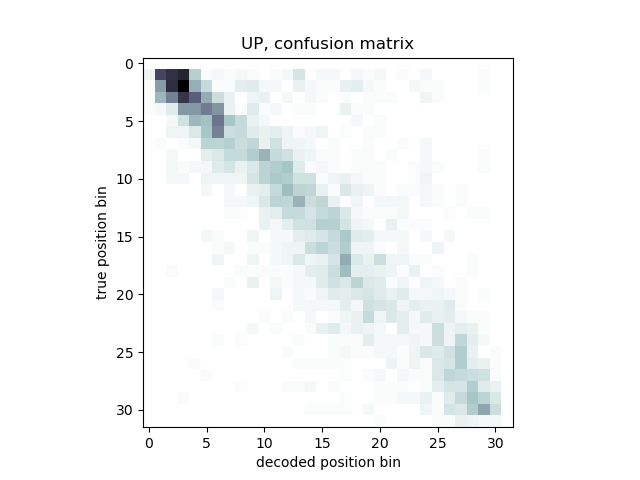

In [50]:
f, axs = plt.subplots(1, 1)
axs.imshow(confusion_mat, aspect='equal', cmap='bone_r')
axs.set_title('UP, confusion matrix')
axs.set_ylabel('true position bin')
axs.set_xlabel('decoded position bin')


### Decoded versus true position..

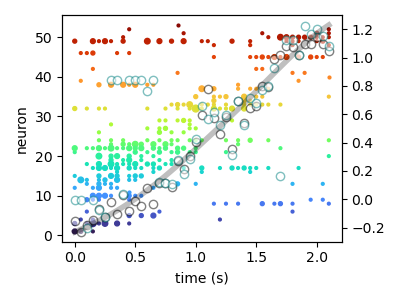

In [51]:
f, axs = plt.subplots(1,1, figsize=(4,3))
ii = 6
imin = upstarts[ii]+1 # 226
imax = upstarts[ii + 1]+1 # 269
itime = i_raster_up[imin:imax]
time_select = time_axis[itime]
for i_cell in sortindex_up:
    ispike = np.flatnonzero(raster[i_cell,itime])
    axs.scatter(time_select[ispike]-time_select[0], np.ones(len(ispike))*i_cell, s=raster[i_cell,itime][ispike]*4, color=cmap(i_cell/N_cells))
axs.set(xlabel='time (s)', ylabel='neuron')
axs2 = axs.twinx()
axs2.set(ylim=(-0.3, 1.3))
axs2.plot(time_select-time_select[0], mean_decoded[imin:imax], 'o', markerfacecolor='w', color='k', alpha=0.5)
axs2.plot(time_select-time_select[0], max_decoded[imin:imax], 'o', markerfacecolor='w', color='teal', alpha=0.5)

posindex = np.flatnonzero((pos[:,0]> tmin) & (pos[:,0] < tmax))
axs2.plot(time_select-time_select[0], pos_up[imin:imax], color='k', alpha=0.25, linewidth=4)

f.tight_layout()
# plt.savefig('raster_run_dt50ms.pdf')

# Exercise

### Decode the down runs - using up ratemaps

In [49]:
mean_decoded = np.zeros_like(pos_down) # posterior mean
max_decoded = np.zeros_like(pos_down) # posterior max
true_bin = np.zeros_like(pos_down) # binned position
confusion_mat = np.zeros((len(posbin_centers), len(posbin_centers)))
for i_bin in np.arange(len(pos_down)):
    log_posterior = np.zeros(len(posbin_centers))
    for i_cell  in np.arange(len(active_cells)):
        log_posterior = log_posterior + poisson.logpmf(raster_down[i_cell,i_bin], rates_up[i_cell,:] * dt)
    unnorm_post = np.exp(log_posterior - np.max(log_posterior))
    post = unnorm_post / np.sum(unnorm_post)
    mean_decoded[i_bin] = np.sum(post * posbin_centers) ## posterior mean

    Fpost = interp1d(posbin_centers, -1*post, fill_value="extrapolate", kind='cubic') 
    res = minimize_scalar(Fpost, bounds=(-0.3, 1.3), method='bounded')    
    max_decoded[i_bin] = res.x ## posterior max

    dec_bin = np.argmin((posbin_centers - mean_decoded[i_bin])**2)
    #
    true_bin[i_bin] = np.argmin((posbin_centers - pos_up[i_bin])**2)
    confusion_mat[int(true_bin[i_bin]), int(dec_bin)] = confusion_mat[int(true_bin[i_bin]), int(dec_bin)] + 1

In [50]:
np.sqrt(np.mean((mean_decoded - pos_down)**2)) ## error in m - posterior mean


0.4586764976636936

In [51]:
np.sqrt(np.mean((max_decoded - pos_down)**2)) ## error in m - posterior mean


0.5366893635230037

Text(0.5, 0, 'decoded position bin')

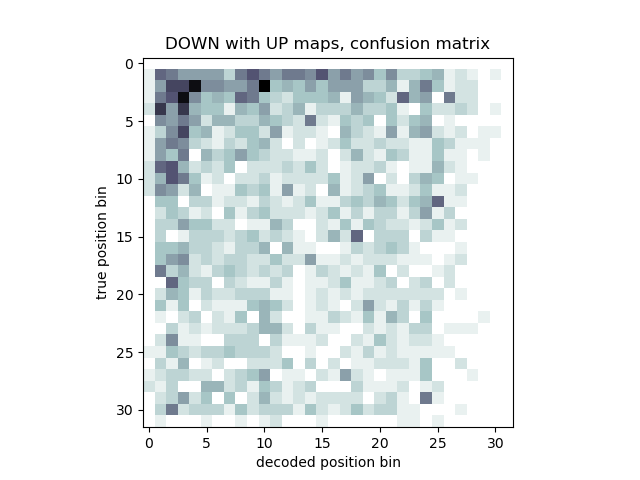

In [53]:
f, axs = plt.subplots(1, 1)
axs.imshow(confusion_mat, aspect='equal', cmap='bone_r')
axs.set_title('DOWN with UP maps, confusion matrix')
axs.set_ylabel('true position bin')
axs.set_xlabel('decoded position bin')


## Homework problems

### 1. Study decoding accuracy

Use different time bins (10ms - 2s) and plot how decoding accuracy changes with the temporal reolution.
Collect a few ideas how you could improve decoding accuracy!

### 2. Theta sequences

- Decode position with 0.025 ms temporal resolution. 
- Zoom in the decoded versus true position data. Can you see epochs where the decoded and the true position changes systematically?
- Calculate the difference between the decoded and the true.
- Calculate the autocorrelation of the difference: can you see any periodicity in the autocorrelation?

### 3. Remapping

- Is the position code similar or different during UP versus DOWN runs?  
- We will quantify the similarity of the two sets of tuning curves (TCs).  
- Estimate TC stability by comparing TCs estimated from even and odd laps on both UP and DOWN runs. This will be an upper bound for similarity.
- Compare up and down TCs. Use different metrics: correlation, that is not sensitive tu the amplitude of the TCs and mean squared error.
- Calculate a lower bound.
- Plot the results: how is the actual similarity compared to the lower and the upper bound? Are the differences significant?

### 4. Grid cells and path integration

- Simulate 1D grid cells and study the effect of noise on path integration.  
- For simplicity, we will simulate the activity of a single grid module as the animal is performing random walk with drift in a linear corridor.  
- The phase of the grid modul can be a single number between 0 and 360. It represents an angle in degrees.  
- As the animal moves with some velocity, the phase of the grid system is updated in each step.  
- The firing rate of the grid cell can be a von Mises function (https://en.wikipedia.org/wiki/Von_Mises_distribution)  
- You can simulate the grid cell spikes by a Poisson process.  
- First use perfect (no noise) updates, and chose the corridor size to be at least 2 x grid periods.  
- Observe the spikes of the grid cell. Are they periodic? How much time do you need to see the periodicity?  
- Add some noise to the updates. How do the results change?
- Estimate the noise level in human path integration. Can you observe grid cells at this noise level?
